## Introduction

In this workflow, we demonstrate how to perform **response prediction** using a **fine-tuned COMPASS model**. COMPASS integrates deep transcriptomic representation learning with biologically grounded concept modeling to predict whether a patient will respond to immune checkpoint inhibitor (ICI) therapy.

The fine-tuned model used here (e.g., `pft_leave_Gide_64.pt`) was trained under a **leave-one-cohort-out (LOCO)** strategy, ensuring generalization across independent clinical cohorts. Once loaded, COMPASS takes as input the patient’s RNA-seq transcriptomic profile (in TPM units) together with the cancer-type code and outputs two key components:

1. **Concept scores** — quantitative activations of 44 high-level tumor immune microenvironment (TIME) concepts (e.g., CD8⁺ T cell, exhausted T cell, IFN-γ pathway). These reflect the inferred biological state of each patient.
2. **Predicted probabilities** — model-estimated likelihoods of therapeutic response (0 = non-responder, 1 = responder).

By comparing the predicted probabilities with ground-truth response labels, we can assess model performance using metrics such as **AUROC**, **AUPRC**, **F1-score**, **accuracy**, and **Matthews correlation coefficient (MCC)**.

This pipeline illustrates the **end-to-end application of COMPASS for immunotherapy response prediction**, from loading a fine-tuned model and preparing input data, to generating response probabilities and evaluating predictive performance across independent cohorts.


In [1]:
import sys
sys.path.insert(0, '/media/ssd/Research/aliyun_sync/aliyun_sync/COMPASS/')
from compass.utils import plot_embed_with_label
from compass import PreTrainer, FineTuner, loadcompass #, get_minmal_epoch
from compass.utils import plot_embed_with_label, plot_performance, score2
from compass.tokenizer import CANCER_CODE

In [2]:
import os
from tqdm import tqdm
from itertools import chain
import pandas as pd
import numpy as np
import random, torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'white', font_scale=1.3)
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

def onehot(S):
    assert type(S) == pd.Series, 'Input type should be pd.Series'
    dfd = pd.get_dummies(S, dummy_na=True)
    nanidx = dfd[dfd[np.nan].astype(bool)].index
    dfd.loc[nanidx, :] = np.nan
    dfd = dfd.drop(columns=[np.nan])*1.
    cols = dfd.sum().sort_values(ascending=False).index.tolist()
    dfd = dfd[cols]
    return dfd

## Download finetuned model
### dowanload the finetuner models from [here](https://www.immuno-compass.com/download/index.html)

In [3]:
## load finetuner, your can load any finetuners
## Here we load finetuner_without_gide.pt to test the Gide cohort performance:

finetuner = loadcompass('./tmpignore/pft_leave_Gide_64.pt', map_location='cpu')

## read data
df_label = pd.read_pickle('./tmpignore/ITRP.PATIENT.TABLE.ALIGN')
df_tpm = pd.read_pickle('./tmpignore/ITRP.TPM.TABLE')

df_label = df_label[df_label.cohort == 'Gide']
df_tpm = df_tpm.loc[df_label.index]

df_tpm.shape, df_label.shape

((73, 15672), (73, 26))

## Prepare model inputs

In [4]:
dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
df_task = onehot(df_label.response_label)
dfcx.head()

,cancer_code,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Index,,,,,,,,,,,,,,,,,,,,,
1_ipiPD1_PRE,25,5.23,0.02,82.96,0.10,0.75,0.03,27.57,3.23,0.04,...,10.48,3.47,0.70,1.63,2.43,0.05,2.98,10.81,6.30,4.01
2_ipiPD1_PRE,25,7.39,0.00,1154.40,0.00,0.95,0.03,48.91,2.10,0.01,...,17.20,7.46,0.44,0.79,5.81,0.00,5.02,37.27,13.47,8.14
6_ipiPD1_PRE,25,3.91,0.00,168.14,0.11,0.52,0.01,18.20,2.08,0.00,...,4.73,1.54,0.57,1.06,1.81,0.01,2.79,4.11,6.77,3.74
7_ipiPD1_PRE,25,1.85,0.01,80.62,0.00,0.21,0.03,4.82,0.84,0.06,...,4.07,1.58,0.44,0.39,0.87,0.00,2.00,8.44,2.20,2.92
8_ipiPD1_PRE,25,5.39,0.00,76.01,0.02,0.81,0.09,49.43,3.93,0.00,...,14.25,10.21,0.89,1.91,3.05,0.03,11.61,17.74,7.96,18.08


## Make predictions

In [5]:
dfe, df_pred = finetuner.predict(dfcx, batch_size = 16)

100%|##################################################################################################| 5/5 [00:04<00:00,  1.16it/s]


The prediction of the model contains 2 outputs. The first output is the score of the cell-type level concepts. The second is the predicted probability. 0 corresponds to non-response and 1 corresponds to response.

In [6]:
## concept score
dfe.head()

,CANCER,Bcell_general,Memory_Bcell,Naive_Bcell,Plasma_cell,CD4_Tcell,CD8_Tcell,Memory_Tcell,Naive_Tcell,Tcell_general,...,Pancreatic,Pneumocyte,Apoptosis_pathway,IFNg_pathway,TGFb_pathway,Cytokine,Cell_proliferation,TLS,Genome_integrity,Reference
Index,,,,,,,,,,,,,,,,,,,,,
1_ipiPD1_PRE,0.777974,0.350095,0.965242,-0.312524,0.743120,0.412816,0.628115,0.706246,0.502847,0.391211,...,0.821949,0.383647,0.745508,0.349143,0.413072,0.629197,0.434206,0.389164,0.686264,0.989591
2_ipiPD1_PRE,0.777928,0.199498,1.312851,-0.324208,0.479462,0.399194,0.646625,0.784448,1.180768,0.498525,...,0.731444,0.503946,0.720887,0.341860,0.535420,0.595845,0.441286,0.583051,0.712418,0.995876
6_ipiPD1_PRE,0.778066,0.169474,0.998816,-0.288887,0.517231,0.430427,0.702656,0.831045,0.902222,0.475890,...,0.800406,0.355487,0.773297,0.432526,0.424019,0.629174,0.417578,0.356560,0.644701,0.985082
7_ipiPD1_PRE,0.778113,0.380925,1.023136,-0.299001,0.649101,0.409610,0.705910,0.734554,0.485680,0.479181,...,0.761324,0.322699,0.892863,0.502239,0.405980,0.661987,0.439342,0.402425,0.636558,0.965560
8_ipiPD1_PRE,0.777857,0.133263,1.040070,-0.339239,0.478219,0.390936,0.732104,0.919124,0.936884,0.464711,...,0.825140,0.390177,0.644346,0.411932,0.378119,0.607818,0.515636,0.458462,0.658638,1.003764


In [7]:
## conceptor prediction probabilities
df_pred.head()

,0,1
Index,,
1_ipiPD1_PRE,0.602607,0.397393
2_ipiPD1_PRE,0.887873,0.112127
6_ipiPD1_PRE,0.463622,0.536379
7_ipiPD1_PRE,0.078182,0.921818
8_ipiPD1_PRE,0.598170,0.401830


## Analysis performance

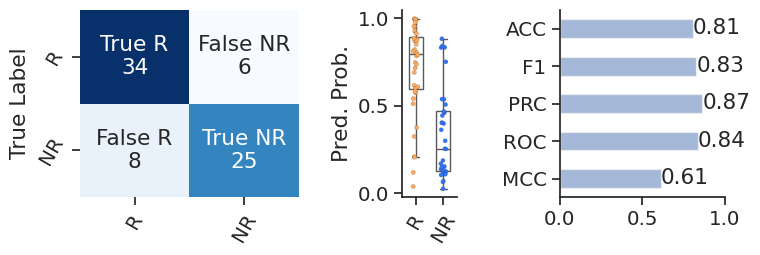

In [8]:
## masure the performance
dfp = df_task.join(df_pred)
y_true, y_prob, y_pred = dfp['R'], dfp[1], dfp[[0, 1]].idxmax(axis=1).astype(float)
fig = plot_performance(y_true, y_prob, y_pred)

In [9]:
roc, prc, f1, acc, mcc = score2(y_true, y_prob, y_pred)
print("Test performance:roc={:.3f},prc={:.3f}, f1={:.3f}, acc={:.3f}, mcc={:.3f}.".format(roc, prc, f1, acc, mcc))

Test performance:roc=0.838,prc=0.866, f1=0.829, acc=0.808, mcc=0.612.
